In [45]:
# Import packages and libraries

In [46]:
import pandas as pd 
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt


In [47]:


df = pd.read_csv(r"C:\Users\AL HAFIZ COMPUTER\Documents\lab files\eda_using_basic_data_functions_in_python_dataset1.csv")

In [48]:
df.head(10)

,date,number_of_strikes,center_point_geom
0,2018-01-03,194,POINT(-75 27)
1,2018-01-03,41,POINT(-78.4 29)
2,2018-01-03,33,POINT(-73.9 27)
3,2018-01-03,38,POINT(-73.8 27)
4,2018-01-03,92,POINT(-79 28)
5,2018-01-03,119,POINT(-78 28)
6,2018-01-03,35,POINT(-79.3 28)
7,2018-01-03,60,POINT(-79.1 28)
8,2018-01-03,41,POINT(-78.7 28)
9,2018-01-03,119,POINT(-78.6 28)


In [49]:
df.shape

# The total number of rows is 3,401,012, and there are three columns

(3401012, 3)

In [50]:
# Get more information about the data, including data types of each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3401012 entries, 0 to 3401011
Data columns (total 3 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   date               object
 1   number_of_strikes  int64 
 2   center_point_geom  object
dtypes: int64(1), object(2)
memory usage: 77.8+ MB


In [51]:
# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"])

In [52]:
# Calculate days with most lightning strikes

df.groupby(['date']).sum().sort_values('number_of_strikes', ascending=False).head(10) 

,number_of_strikes,center_point_geom
date,,
2018-08-29,1070457,POINT(-85.7 29.1)POINT(-85.6 29.1)POINT(-84.5 ...
2018-08-17,969774,POINT(-80.6 20.3)POINT(-80.5 20.3)POINT(-80.4 ...
2018-08-28,917199,POINT(-108.2 28)POINT(-108.1 28)POINT(-108 28)...
2018-08-27,824589,POINT(-109 24.8)POINT(-108 24.8)POINT(-88.1 24...
2018-08-30,802170,POINT(-75.7 19)POINT(-75.6 19)POINT(-78 20)POI...
2018-08-19,786225,POINT(-73 35)POINT(-103 35)POINT(-101 35)POINT...
2018-08-18,741180,POINT(-110.7 46)POINT(-104.9 46)POINT(-115.1 4...
2018-08-16,734475,POINT(-97 20)POINT(-77 20)POINT(-96.9 20)POINT...
2018-08-31,723624,POINT(-95.2 48.4)POINT(-96 48.1)POINT(-96.1 48...


In [53]:
#                                                     Extract the month data

# Create a new `month` column
df["month"] = df["date"].dt.month
df.head()

,date,number_of_strikes,center_point_geom,month
0,2018-01-03,194,POINT(-75 27),1
1,2018-01-03,41,POINT(-78.4 29),1
2,2018-01-03,33,POINT(-73.9 27),1
3,2018-01-03,38,POINT(-73.8 27),1
4,2018-01-03,92,POINT(-79 28),1


In [54]:
#                                        Calculate the number of strikes per month

df.groupby("month")["number_of_strikes"].sum().sort_values(ascending=False).head(12)

month
8     15525255
7      8320400
6      6445083
5      4166726
9      3018336
2      2071315
4      1524339
10     1093962
1       860045
3       854168
11      409263
12      312097
Name: number_of_strikes, dtype: int64

In [55]:
#                                            Convert the month  to text
                                         #-------------------------------------

# Create a new `month_txt` column.
df["month_txt"] = df["date"].dt.month_name().str.slice(stop = 3)
df.head()

,date,number_of_strikes,center_point_geom,month,month_txt
0,2018-01-03,194,POINT(-75 27),1,Jan
1,2018-01-03,41,POINT(-78.4 29),1,Jan
2,2018-01-03,33,POINT(-73.9 27),1,Jan
3,2018-01-03,38,POINT(-73.8 27),1,Jan
4,2018-01-03,92,POINT(-79 28),1,Jan


In [59]:
                                                      #Create a new dataframe
                                                #---------------------------------

# Create a new helper dataframe for plotting.
df_by_month = (
    df.groupby(["month", "month_txt"])["number_of_strikes"]
      .sum()
      .reset_index()
      .sort_values("month", ascending=True)
)

df_by_month

,month,month_txt,number_of_strikes
0,1,Jan,860045
1,2,Feb,2071315
2,3,Mar,854168
3,4,Apr,1524339
4,5,May,4166726
5,6,Jun,6445083
6,7,Jul,8320400
7,8,Aug,15525255
8,9,Sep,3018336
9,10,Oct,1093962


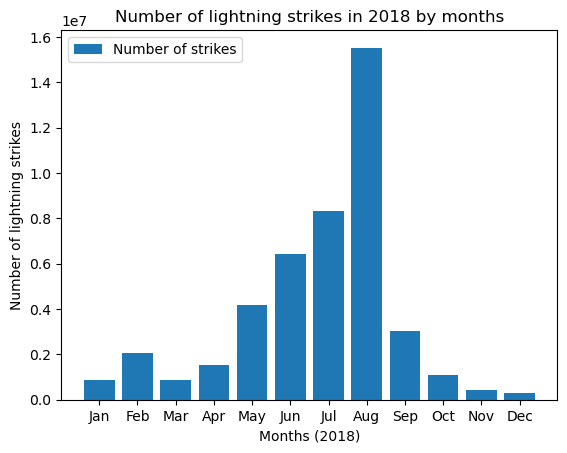

In [61]:
                                                           # Make a bar chart


plt.bar(
    x=df_by_month['month_txt'],
    height=df_by_month['number_of_strikes'],
    label="Number of strikes"
)

plt.xlabel("Months (2018)")
plt.ylabel("Number of lightning strikes")
plt.title("Number of lightning strikes in 2018 by months")

plt.legend()
plt.show()